# 06 · Sky Images: 15-Minute Forecasting with a CNN

**Why sky images?** Notebook 04 showed that even *perfect* weather data barely helps, because weather
models can't see the individual clouds over one building. A camera pointed at the sky **can**.

**Data:** the SKIPP'D benchmark (Stanford, CC BY 4.0). 64×64 sky images and PV power, one per minute,
March 2017 – October 2019. Downloaded with `python -m src.skippd`.

**Task (the benchmark task):** predict PV power **15 minutes ahead**.
**Split:** the dataset's **official test set (20 days)**, so results can be compared with published work.
All other days are for training, with every 5th training day held out for validation.

**Three contenders:**

| Model | Sees |
|---|---|
| Smart persistence | current power + the sun's curve (pvlib) |
| Numbers-only model (Gradient Boosting) | power over the last 15 min, sun position, clear-sky sunlight |
| **Sky CNN** | the same numbers **+ two sky images** (now and 6 minutes ago) |

Comparing the last two answers the key question: **do the images add real information?**

⏱ This notebook trains a neural network. On an Apple-chip Mac expect about **15–40 minutes** in total.

In [14]:
import os, sys, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.ensemble import HistGradientBoostingRegressor

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.skyimages import SKIPPD_DIR, NUMERIC_FEATURES, HORIZON, LAG, build_samples, smart_persistence, load_images, read_raw_times
import pvlib
from src.skycnn import SkyDataset, SkyCNN, pick_device, train, predict
from src.metrics import rmse, mae, skill

FIGURES, RESULTS = ROOT / "results" / "figures", ROOT / "results"
(RESULTS / "models").mkdir(exist_ok=True)

QUICK = os.environ.get("SKY_QUICK") == "1"     # small test run (used when checking the code)
torch.manual_seed(42); np.random.seed(42)
device = pick_device()
print("Training on:", device)

Training on: mps


## Step 0 · A data-quality check on the timestamps

Before modelling, check that the clock is right. A simple physics test: on any day, solar power should be
centred around **solar noon**, when the sun is due south (azimuth ≈ 180°). For each day we compute the
**power-weighted average sun direction**. It should be about the same in winter and summer.

In [15]:
files = sorted(SKIPPD_DIR.glob("*.parquet"))
raw = read_raw_times(files)
local = raw["time"].dt.tz_convert("America/Los_Angeles")
in_dst = np.array([t.dst() != pd.Timedelta(0) for t in local])
site = pvlib.location.Location(37.427, -122.174, altitude=30)

def weighted_azimuth(times):
    az = site.get_solarposition(pd.DatetimeIndex(times))["azimuth"].to_numpy()
    d = pd.DataFrame({"day": times.dt.date.to_numpy(), "w": raw["pv"].to_numpy(), "az": az, "dst": in_dst})
    daily = d.groupby("day").apply(lambda g: pd.Series({"az": np.average(g.az, weights=g.w), "dst": g.dst.iloc[0]}))
    return daily.groupby("dst")["az"].mean()

check = pd.DataFrame({
    "original timestamps": weighted_azimuth(local),
    "summer times moved back 1 h": weighted_azimuth(local - pd.to_timedelta(in_dst.astype(int), unit="h")),
}).rename(index={False: "winter (standard time)", True: "summer (daylight saving)"})
check.round(1)

,original timestamps,summer times moved back 1 h
dst,,
winter (standard time),183.1,183.1
summer (daylight saving),206.1,186.4


**Finding:** with the original timestamps, summer days look centred on the sun at about 205° (south-west),
but winter days on about 187°. That's physically impossible for the same fixed panels. After moving the
summer (daylight-saving) timestamps **back 1 hour**, both seasons agree. So in this data release, times
during daylight saving are 1 hour late. `build_samples()` corrects this automatically.

(Without this fix, the sun-position features and smart persistence would be off by an hour for most of
the year, for example predicting sunset an hour too early.)

## Step 1 · Build the samples

For each minute *t* we need: the power at *t*, *t−5*, *t−10* and *t−15*, the images at *t* and *t−6*,
and the **target**, the power at *t+15*. Minutes where anything is missing are skipped.

To save memory, training uses **every 3rd minute** (neighbouring minutes are almost identical anyway).
The test set uses **every minute**.

In [16]:
train_files = sorted(SKIPPD_DIR.glob("train-*.parquet"))
test_files = [SKIPPD_DIR / "test-00000-of-00001.parquet"]
if QUICK:
    train_files = train_files[:1]
print("Training files:", [f.name for f in train_files])

train_all, train_frames = build_samples(train_files, stride=3)
test, test_frames = build_samples(test_files, stride=1)

days = sorted(train_all["day"].unique())
if QUICK:
    days = days[::4]
    train_all = train_all[train_all["day"].isin(days)]
val_days = set(days[::5])                                   # every 5th training day -> validation
val = train_all[train_all["day"].isin(val_days)]
train_s = train_all[~train_all["day"].isin(val_days)]

print(f"train: {len(train_s):,} samples on {train_s['day'].nunique()} days")
print(f"val:   {len(val):,} samples on {val['day'].nunique()} days")
print(f"test:  {len(test):,} samples on {test['day'].nunique()} days (official test set)")

Training files: ['train-00000-of-00005.parquet', 'train-00001-of-00005.parquet', 'train-00002-of-00005.parquet', 'train-00003-of-00005.parquet', 'train-00004-of-00005.parquet']
train: 87,488 samples on 397 days
val:   22,461 samples on 100 days
test:  13,330 samples on 20 days (official test set)


## Step 2 · What the camera sees

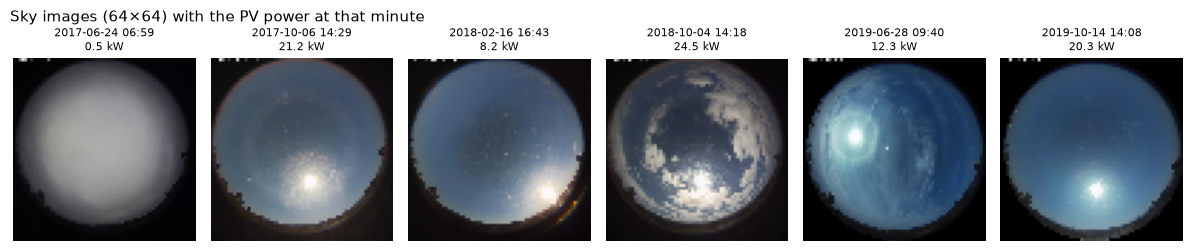

In [17]:
examples, ex_pos = load_images(test_frames, test.index[::2500][:6])
fig, axes = plt.subplots(1, 6, figsize=(12, 2.6))
for ax, t in zip(axes, test.index[::2500][:6]):
    ax.imshow(examples[ex_pos[t]])
    ax.set_title(f"{t:%Y-%m-%d %H:%M}\n{test.loc[t, 'pv_lag0']:.1f} kW", fontsize=8)
    ax.axis("off")
fig.suptitle("Sky images (64×64) with the PV power at that minute", x=0.01, ha="left", fontsize=11)
fig.tight_layout()
fig.savefig(FIGURES / "06_sky_examples.png", dpi=130)
plt.show()

## Step 3 · The two non-image contenders

In [18]:
forecasts = {"Smart persistence": smart_persistence(test)}

# Like the CNN, the Gradient Boosting model learns a CORRECTION to smart persistence (fair comparison)
gb = HistGradientBoostingRegressor(max_iter=500, learning_rate=0.05, random_state=42)
gb.fit(train_s[NUMERIC_FEATURES], train_s["target"] - smart_persistence(train_s))
forecasts["Numbers-only (Gradient Boosting)"] = np.clip(smart_persistence(test) + gb.predict(test[NUMERIC_FEATURES]), 0, None)

for name, p in forecasts.items():
    print(f"{name:35s} RMSE {rmse(test['target'], p):.3f} kW")

Smart persistence                   RMSE 3.607 kW
Numbers-only (Gradient Boosting)    RMSE 3.161 kW


## Step 4 · Load the images into memory

Only the images the samples need are decoded (PNG → numbers). This is the slowest non-training step.

In [19]:
start = time.time()
train_images, train_pos = load_images(train_frames, list(train_all["img_now"]) + list(train_all["img_before"]))
test_images, test_pos = load_images(test_frames, list(test["img_now"]) + list(test["img_before"]))
print(f"{len(train_images):,} training images + {len(test_images):,} test images "
      f"({(train_images.nbytes + test_images.nbytes) / 1e9:.1f} GB) in {time.time() - start:.0f}s")

111,221 training images + 13,463 test images (1.5 GB) in 14s


## Step 5 · The sky CNN

**Architecture:**

- **Image branch (CNN):** the two images are stacked into 6 colour channels
  (red, green, blue now + red, green, blue 6 minutes ago), so the network can see **cloud movement**.
  Three blocks of *convolution → batch normalisation → ReLU → max-pool* shrink 64×64 to 8×8,
  then the result is flattened into 128 numbers.
- **Numeric branch:** a small network for the 11 numbers (recent power, sun position…).
- **Head:** combines both and outputs one number.

**Residual learning (the key trick):** the network does **not** predict the power from scratch. It
predicts a **correction to smart persistence**:

> forecast = smart persistence + CNN correction

At the start it outputs roughly 0, so it begins as good as smart persistence and only has to learn
*when and how much to adjust*, for example "a cloud is about to cover the sun, so lower the forecast".
This made training much more stable in our tests.

**Early stopping:** after every epoch (one pass over the training data) we check the validation RMSE,
and keep the best weights. If there's no improvement for 3 epochs, training stops.

In [20]:
mean, std = train_s[NUMERIC_FEATURES].mean(), train_s[NUMERIC_FEATURES].std()
loaders = {}
for name, df, im, pos, shuffle in [("train", train_s, train_images, train_pos, True),
                                   ("val", val, train_images, train_pos, False),
                                   ("test", test, test_images, test_pos, False)]:
    loaders[name] = torch.utils.data.DataLoader(SkyDataset(df, im, pos, mean, std),
                                                batch_size=256 if shuffle else 1024, shuffle=shuffle)

model = SkyCNN(len(NUMERIC_FEATURES))
print(f"{sum(p.numel() for p in model.parameters()):,} trainable parameters")

model, history = train(model, loaders["train"], loaders["val"], val["target"].to_numpy(), device,
                       max_epochs=3 if QUICK else 12)
torch.save(model.state_dict(), RESULTS / "models" / "sky_cnn.pt")

247,297 trainable parameters
epoch  1  train loss 0.0421  val RMSE 2.063 kW  (63s)
epoch  2  train loss 0.0359  val RMSE 2.002 kW  (68s)
epoch  3  train loss 0.0340  val RMSE 1.977 kW  (69s)
epoch  4  train loss 0.0331  val RMSE 1.986 kW  (63s)
epoch  5  train loss 0.0324  val RMSE 2.054 kW  (69s)
epoch  6  train loss 0.0314  val RMSE 2.065 kW  (71s)
stopping early: no improvement for 3 epochs


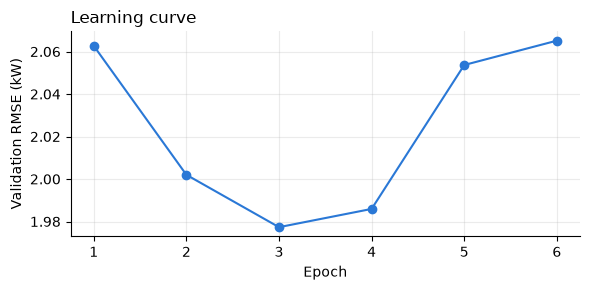

In [21]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(history["epoch"], history["val_rmse"], marker="o", color="#2a78d6")
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation RMSE (kW)")
ax.set_title("Learning curve", loc="left")
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURES / "06_learning_curve.png", dpi=130)
plt.show()

## Step 6 · Results on the 20 official test days

In [22]:
forecasts["Sky CNN (images + numbers)"] = predict(model, loaders["test"], device)

y_test = test["target"].to_numpy()
ref = rmse(y_test, forecasts["Smart persistence"])
table = pd.DataFrame({name: {"MAE (kW)": mae(y_test, p), "RMSE (kW)": rmse(y_test, p),
                             "Skill vs smart persistence": skill(rmse(y_test, p), ref)}
                      for name, p in forecasts.items()}).T
table.round(3)

,MAE (kW),RMSE (kW),Skill vs smart persistence
Smart persistence,1.673,3.607,0.000
Numbers-only (Gradient Boosting),1.558,3.161,0.124
Sky CNN (images + numbers),1.570,2.920,0.190


**Sunny vs cloudy days.** The test set mixes clear and cloudy days. We split the 20 days in half by how
much the power jumped around (the average minute-to-minute change). Sky images should help most on the
cloudy, "jumpy" days.

In [23]:
jumpiness = test.groupby("day")["pv_lag0"].apply(lambda s: s.diff().abs().mean())
cloudy_days = set(jumpiness.sort_values().index[len(jumpiness) // 2:])
test_type = np.where(test["day"].isin(cloudy_days), "Cloudy days", "Clear days")

rows = []
for kind in ["Clear days", "Cloudy days"]:
    m = test_type == kind
    r_ref = rmse(y_test[m], forecasts["Smart persistence"][m])
    for name, p in forecasts.items():
        rows.append({"days": kind, "model": name, "MAE (kW)": mae(y_test[m], p[m]), "RMSE (kW)": rmse(y_test[m], p[m]),
                     "Skill vs smart persistence": skill(rmse(y_test[m], p[m]), r_ref)})
by_type = pd.DataFrame(rows)
by_type.pivot(index="model", columns="days", values="RMSE (kW)").round(3)

days,Clear days,Cloudy days
model,,
Numbers-only (Gradient Boosting),0.248,4.462
Sky CNN (images + numbers),0.367,4.112
Smart persistence,0.356,5.087


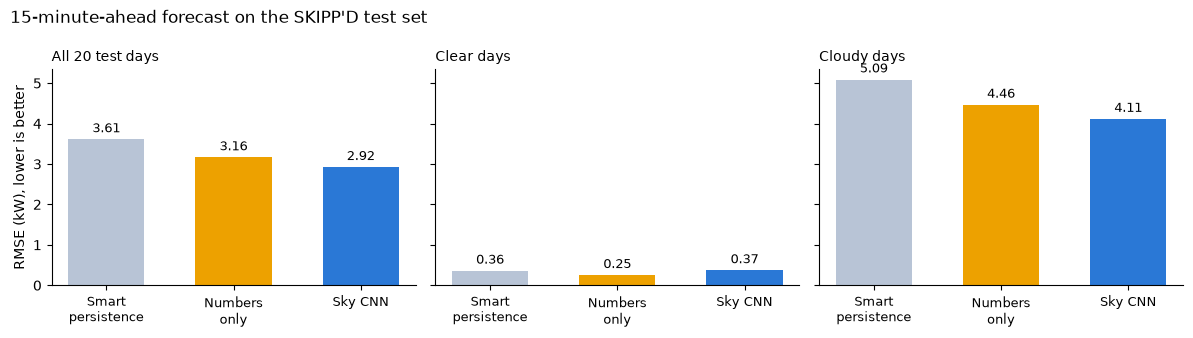

In [24]:
names = list(forecasts)
colors = ["#b8c4d6", "#eda100", "#2a78d6"]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)
for ax, (title, subset) in zip(axes, [("All 20 test days", None), ("Clear days", "Clear days"), ("Cloudy days", "Cloudy days")]):
    vals = [table.loc[n, "RMSE (kW)"] if subset is None else
            by_type[(by_type.days == subset) & (by_type.model == n)]["RMSE (kW)"].iloc[0] for n in names]
    bars = ax.bar(range(3), vals, color=colors, width=0.6)
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
    ax.set_xticks(range(3), ["Smart\npersistence", "Numbers\nonly", "Sky CNN"], fontsize=9)
    ax.set_title(title, loc="left", fontsize=10)
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
axes[0].set_ylabel("RMSE (kW), lower is better")
fig.suptitle("15-minute-ahead forecast on the SKIPP'D test set", x=0.01, ha="left", fontsize=12)
fig.tight_layout()
fig.savefig(FIGURES / "06_sky_cnn_results.png", dpi=130)
plt.show()

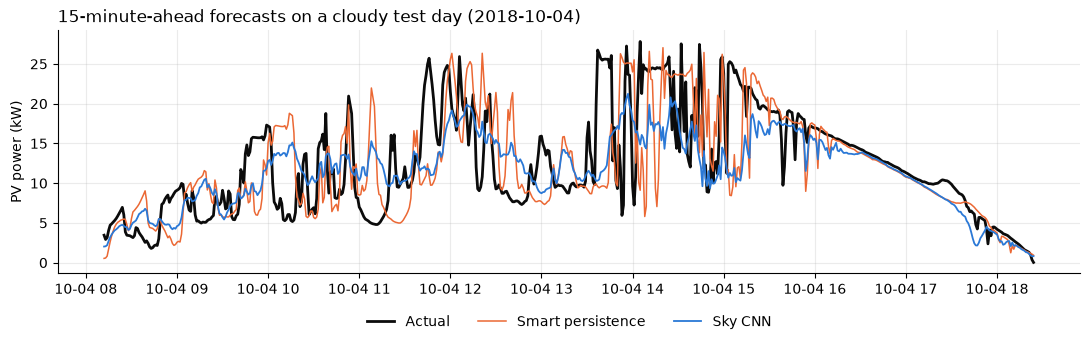

In [25]:
day = sorted(cloudy_days)[len(cloudy_days) // 2]
m = (test["day"] == day).to_numpy()
t_target = test.index[m] + pd.Timedelta(minutes=HORIZON)

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(t_target, y_test[m], color="#0b0b0b", linewidth=2, label="Actual")
ax.plot(t_target, forecasts["Smart persistence"][m], color="#eb6834", linewidth=1.1, label="Smart persistence")
ax.plot(t_target, forecasts["Sky CNN (images + numbers)"][m], color="#2a78d6", linewidth=1.3, label="Sky CNN")
ax.set_ylabel("PV power (kW)")
ax.set_title(f"15-minute-ahead forecasts on a cloudy test day ({day})", loc="left")
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.12), frameon=False)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIGURES / "06_cloudy_day.png", dpi=130)
plt.show()

In [26]:
out = pd.concat({"all days": table,
                 **{k: by_type[by_type.days == k].set_index("model").drop(columns="days") for k in ["Clear days", "Cloudy days"]}},
                names=["subset", "model"])
if not QUICK:
    out.to_csv(RESULTS / "metrics_sky_images.csv")
out.round(3)

MAE (kW)  RMSE (kW)  \
subset      model                                                   
all days    Smart persistence                    1.673      3.607   
            Numbers-only (Gradient Boosting)     1.558      3.161   
            Sky CNN (images + numbers)           1.570      2.920   
Clear days  Smart persistence                    0.268      0.356   
            Numbers-only (Gradient Boosting)     0.182      0.248   
            Sky CNN (images + numbers)           0.281      0.367   
Cloudy days Smart persistence                    3.077      5.087   
            Numbers-only (Gradient Boosting)     2.931      4.462   
            Sky CNN (images + numbers)           2.858      4.112   

                                              Skill vs smart persistence  
subset      model                                                         
all days    Smart persistence                                      0.000  
            Numbers-only (Gradient Boosting)                       0.124  
            Sky CNN (images + numbers)                             0.190  
Clear days  Smart persistence                                      0.000  
            Numbers-only (Gradient Boosting)                       0.303  
            Sky CNN (images + numbers)                            -0.031  
Cloudy days Smart persistence                                      0.000  
            Numbers-only (Gradient Boosting)                       0.123  
            Sky CNN (images + numbers)                             0.192

## What we learned

- **The sky images add real information.** On the 20 official test days the Sky CNN reaches an RMSE of
  **2.92 kW**, compared with **3.16 kW** for the same inputs without images and **3.61 kW** for smart
  persistence. That's a skill of **0.19** vs 0.12.
- **The gain comes from cloudy days** (4.11 vs 4.46 vs 5.09 kW). On clear days every model is already
  very accurate (about 0.3 kW), and the numbers-only model is slightly better there. Images matter when
  clouds are moving.
- **A data-quality fix was essential.** In this release, timestamps during daylight saving time are
  1 hour late. Correcting them cut smart persistence's error on clear days from about 1.4 to 0.36 kW.
- **Training was short and stable.** With residual learning (correcting smart persistence), the best
  validation score came at epoch 3 of 6, about 7 minutes on an Apple-chip Mac. Early stopping prevented
  overfitting.

**Limitations (honest):**

- On very variable days the CNN's forecast is **smoother than reality**. When unsure whether a cloud will
  cover the sun, a model trained on squared error hedges towards the middle.
- Only **two images** (now and 6 minutes ago) are used, at 64×64 pixels. Longer image sequences, or
  predicting cloud motion directly, could do better.
- One run with one random seed. Repeating with several seeds would show how stable the numbers are.

**Next ideas:** use more past images (a video-style model), predict ranges with conformal prediction
as in notebook 05, and try longer horizons (30–60 minutes).
